In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")


✅ Libraries imported!


In [2]:
df_oct = pd.read_parquet('../data/raw/yellow_tripdata_2025-10.parquet')
df_nov = pd.read_parquet('../data/raw/yellow_tripdata_2025-11.parquet')

# Combine
df = pd.concat([df_oct, df_nov], ignore_index=True)

print(f"✅ Data loaded!")
print(f"Total records: {len(df):,}")
print(f"Date range: {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")

✅ Data loaded!
Total records: 8,610,143
Date range: 2008-12-31 23:04:21 to 2025-11-30 23:59:59


In [3]:
def clean_data(df):
    """Remove invalid and outlier records"""
    print(f"Original records: {len(df):,}")
    
    df = df.copy()
    
    # Remove invalid pickup zones
    df = df[df['PULocationID'].notna()]
    df = df[df['PULocationID'] > 0]
    print(f"After removing invalid zones: {len(df):,}")
    
    # Remove invalid trip distances (0 or too long)
    df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
    print(f"After removing invalid distances: {len(df):,}")
    
    # Remove invalid fares
    df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
    print(f"After removing invalid fares: {len(df):,}")
    
    # Remove invalid passenger counts
    df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
    print(f"After removing invalid passengers: {len(df):,}")
    
    # Remove trips with invalid duration (less than 1 min or more than 3 hours)
    df['trip_duration'] = (pd.to_datetime(df['tpep_dropoff_datetime']) - 
                           pd.to_datetime(df['tpep_pickup_datetime'])).dt.total_seconds() / 60
    df = df[(df['trip_duration'] >= 1) & (df['trip_duration'] <= 180)]
    print(f"After removing invalid durations: {len(df):,}")
    
    print(f"\n✅ Cleaning complete! Kept {len(df):,} records ({len(df)/len(df)*100:.1f}% of original)")
    
    return df

# Clean the data
df_clean = clean_data(df)

Original records: 8,610,143
After removing invalid zones: 8,610,143
After removing invalid distances: 8,374,672
After removing invalid fares: 7,714,621
After removing invalid passengers: 6,367,726
After removing invalid durations: 6,213,974

✅ Cleaning complete! Kept 6,213,974 records (100.0% of original)


In [4]:
df_clean.to_parquet('../data/processed/cleaned_trips.parquet', index=False)
print("✅ Cleaned data saved to: data/processed/cleaned_trips.parquet")

✅ Cleaned data saved to: data/processed/cleaned_trips.parquet


In [5]:
def aggregate_demand(df):
    """Create hourly demand counts per zone"""
    print("Aggregating demand by zone and hour...")
    
    df = df.copy()
    
    # Convert to datetime
    df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    
    # Extract time components
    df['date'] = df['pickup_datetime'].dt.date
    df['hour'] = df['pickup_datetime'].dt.hour
    
    # Count trips per zone per hour
    demand = df.groupby(['date', 'hour', 'PULocationID']).agg({
        'VendorID': 'count',  # Count trips
        'trip_distance': 'mean',  # Average trip distance
        'fare_amount': 'mean'  # Average fare
    }).reset_index()
    
    demand.columns = ['date', 'hour', 'PULocationID', 'demand', 'avg_distance', 'avg_fare']
    
    print(f"✅ Aggregated to {len(demand):,} records (zone-hour combinations)")
    print(f"Date range: {demand['date'].min()} to {demand['date'].max()}")
    print(f"Number of unique zones: {demand['PULocationID'].nunique()}")
    
    return demand

demand_df = aggregate_demand(df_clean)
demand_df.head(10)

Aggregating demand by zone and hour...
✅ Aggregated to 181,865 records (zone-hour combinations)
Date range: 2008-12-31 to 2025-11-30
Number of unique zones: 259


,date,hour,PULocationID,demand,avg_distance,avg_fare
0,2008-12-31,23,132,1,18.12,70.0
1,2009-01-01,0,239,1,1.26,8.6
2,2009-01-01,14,138,1,11.56,50.6
3,2025-09-30,22,164,1,1.77,11.4
4,2025-09-30,23,79,1,5.83,31.0
5,2025-09-30,23,107,1,3.14,15.6
6,2025-09-30,23,140,1,2.77,12.8
7,2025-09-30,23,142,1,2.73,15.6
8,2025-09-30,23,161,1,1.16,8.6
9,2025-09-30,23,211,1,0.50,5.1


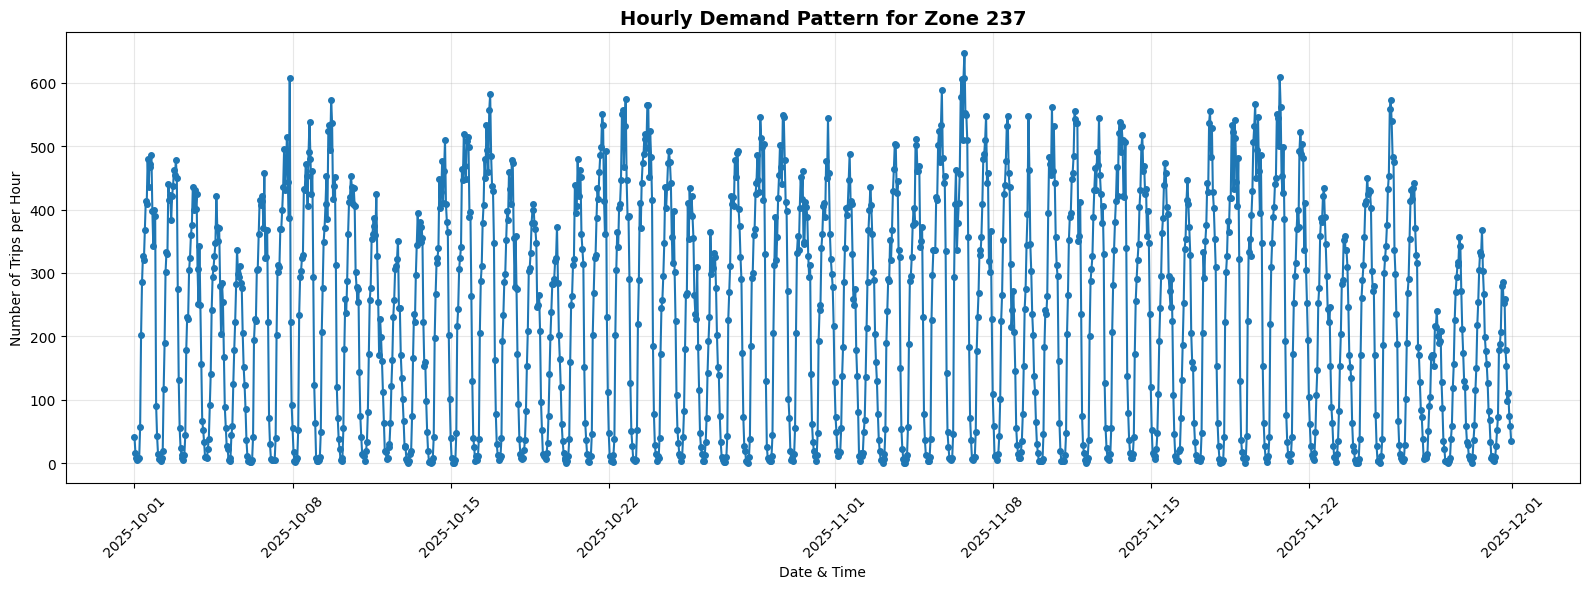

Average hourly demand: 237.5 trips
Peak demand: 647 trips


In [6]:
sample_zone = 237

zone_data = demand_df[demand_df['PULocationID'] == sample_zone].copy()
zone_data['datetime'] = pd.to_datetime(zone_data['date']) + pd.to_timedelta(zone_data['hour'], unit='h')

plt.figure(figsize=(16, 6))
plt.plot(zone_data['datetime'], zone_data['demand'], marker='o', linewidth=1.5, markersize=4)
plt.title(f'Hourly Demand Pattern for Zone {sample_zone}', fontsize=14, fontweight='bold')
plt.xlabel('Date & Time')
plt.ylabel('Number of Trips per Hour')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Average hourly demand: {zone_data['demand'].mean():.1f} trips")
print(f"Peak demand: {zone_data['demand'].max()} trips")


In [7]:
demand_df.to_parquet('../data/processed/demand_aggregated.parquet', index=False)
print("✅ Aggregated demand saved to: data/processed/demand_aggregated.parquet")

✅ Aggregated demand saved to: data/processed/demand_aggregated.parquet


In [8]:
def create_features(demand_df):
    """Create features for machine learning"""
    print("Creating features for ML...")
    
    df = demand_df.copy()
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # === TEMPORAL FEATURES ===
    df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Time of day categories
    df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
    df['is_evening_rush'] = ((df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
    
    print("✅ Created temporal features")
    
    # === LAG FEATURES (Historical Demand) ===
    # Sort by location and time
    df = df.sort_values(['PULocationID', 'date', 'hour']).reset_index(drop=True)
    
    print("Creating lag features (this may take a minute)...")
    
    # Demand 1 hour ago
    df['demand_lag_1h'] = df.groupby('PULocationID')['demand'].shift(1)
    
    # Demand 24 hours ago (same hour yesterday)
    df['demand_lag_24h'] = df.groupby('PULocationID')['demand'].shift(24)
    
    # Demand 168 hours ago (same hour last week)
    df['demand_lag_168h'] = df.groupby('PULocationID')['demand'].shift(168)
    
    print("✅ Created lag features")
    
    # === ROLLING STATISTICS ===
    print("Creating rolling statistics...")
    
    # Average demand in last 3 hours
    df['demand_rolling_mean_3h'] = df.groupby('PULocationID')['demand'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
    )
    
    # Max demand in last 6 hours
    df['demand_rolling_max_6h'] = df.groupby('PULocationID')['demand'].transform(
        lambda x: x.rolling(window=6, min_periods=1).max().shift(1)
    )
    
    # Standard deviation of demand in last 6 hours
    df['demand_rolling_std_6h'] = df.groupby('PULocationID')['demand'].transform(
        lambda x: x.rolling(window=6, min_periods=1).std().shift(1)
    )
    
    print("✅ Created rolling features")
    
    # Drop rows with NaN (from lag features)
    original_len = len(df)
    df = df.dropna()
    print(f"Dropped {original_len - len(df):,} rows with missing lag values")
    
    print(f"\n✅ Feature engineering complete!")
    print(f"Final dataset: {len(df):,} records with {len(df.columns)} columns")
    
    return df

feature_df = create_features(demand_df)
print(f"\nFeature columns: {feature_df.columns.tolist()}")
feature_df.head(10)

Creating features for ML...
✅ Created temporal features
Creating lag features (this may take a minute)...
✅ Created lag features
Creating rolling statistics...
✅ Created rolling features
Dropped 38,019 rows with missing lag values

✅ Feature engineering complete!
Final dataset: 143,846 records with 20 columns

Feature columns: ['date', 'hour', 'PULocationID', 'demand', 'avg_distance', 'avg_fare', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_night', 'is_business_hours', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_rolling_mean_3h', 'demand_rolling_max_6h', 'demand_rolling_std_6h']


,date,hour,PULocationID,demand,avg_distance,avg_fare,day_of_week,day_of_month,month,is_weekend,is_morning_rush,is_evening_rush,is_night,is_business_hours,demand_lag_1h,demand_lag_24h,demand_lag_168h,demand_rolling_mean_3h,demand_rolling_max_6h,demand_rolling_std_6h
262,2025-10-31,19,3,1,7.700,39.50,4,31,10,0,0,1,0,0,1.0,1.0,3.0,1.000000,2.0,0.408248
263,2025-11-01,16,3,1,10.500,40.50,5,1,11,1,0,0,0,1,1.0,1.0,1.0,1.000000,1.0,0.000000
264,2025-11-02,9,3,1,1.800,18.50,6,2,11,1,1,0,0,1,1.0,1.0,1.0,1.000000,1.0,0.000000
265,2025-11-03,0,3,1,18.200,55.50,0,3,11,0,0,0,1,0,1.0,1.0,1.0,1.000000,1.0,0.000000
266,2025-11-03,6,3,4,13.725,44.25,0,3,11,0,0,0,0,0,1.0,1.0,1.0,1.000000,1.0,0.000000
267,2025-11-03,7,3,2,12.300,43.00,0,3,11,0,1,0,0,0,4.0,1.0,2.0,2.000000,4.0,1.224745
268,2025-11-03,11,3,2,14.650,46.00,0,3,11,0,0,0,0,1,2.0,1.0,1.0,2.333333,4.0,1.211060
269,2025-11-03,12,3,2,14.150,46.00,0,3,11,0,0,0,0,1,2.0,1.0,1.0,2.666667,4.0,1.169045
270,2025-11-03,13,3,1,13.600,48.50,0,3,11,0,0,0,0,1,2.0,1.0,1.0,2.000000,4.0,1.095445
271,2025-11-03,17,3,1,10.000,37.50,0,3,11,0,0,1,0,1,1.0,2.0,1.0,1.666667,4.0,1.095445


In [9]:
print("Feature Statistics:")
print("="*60)
print(feature_df.describe())

Feature Statistics:
                                date           hour   PULocationID  \
count                         143846  143846.000000  143846.000000   
mean   2025-11-05 13:12:49.072480256      11.963238     140.766466   
min              2025-10-07 00:00:00       0.000000       3.000000   
25%              2025-10-24 00:00:00       7.000000      75.000000   
50%              2025-11-06 00:00:00      12.000000     142.000000   
75%              2025-11-18 00:00:00      17.000000     215.000000   
max              2025-11-30 00:00:00      23.000000     265.000000   
std                              NaN       6.211632      75.761871   

              demand   avg_distance       avg_fare    day_of_week  \
count  143846.000000  143846.000000  143846.000000  143846.000000   
mean       38.159643       5.888101      28.078116       3.064110   
min         1.000000       0.010000       0.010000       0.000000   
25%         1.000000       2.290467      15.485139       1.000000   
50% 

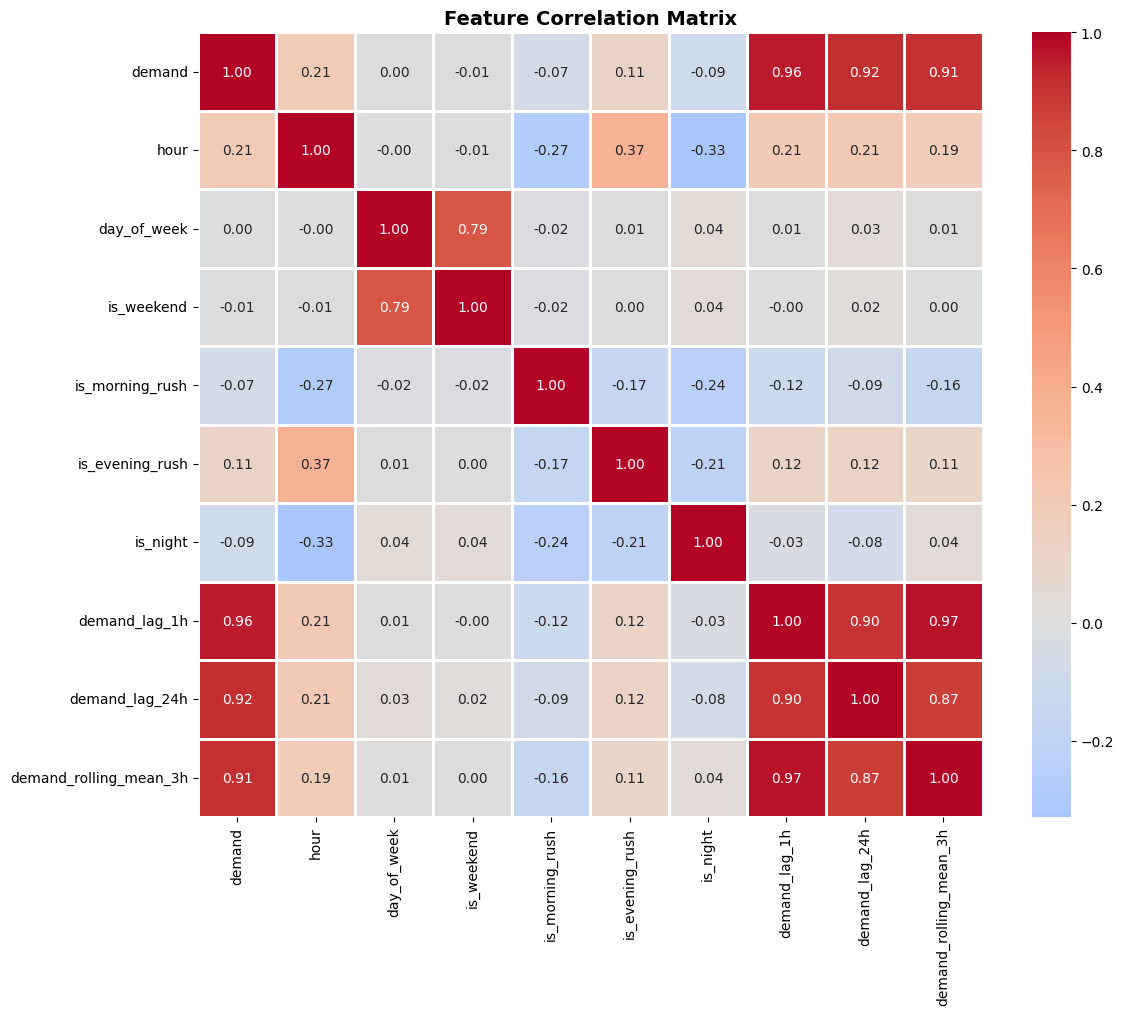

In [10]:
numeric_cols = ['demand', 'hour', 'day_of_week', 'is_weekend', 
                'is_morning_rush', 'is_evening_rush', 'is_night',
                'demand_lag_1h', 'demand_lag_24h', 'demand_rolling_mean_3h']

plt.figure(figsize=(12, 10))
correlation_matrix = feature_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
feature_df.to_parquet('../data/processed/features_for_ml.parquet', index=False)
print("✅ Feature dataset saved to: data/processed/features_for_ml.parquet")
print(f"Shape: {feature_df.shape}")
print("\n🎯 Data preparation complete! Ready for model training!")

✅ Feature dataset saved to: data/processed/features_for_ml.parquet
Shape: (143846, 20)

🎯 Data preparation complete! Ready for model training!
